# Analisis de precios [SEPA](https://datos.produccion.gob.ar/dataset/sepa-precios) minoristas

**Fuentes**:

[2018-2023](https://drive.google.com/drive/folders/13GONeBs5lQCSUdBioHYk-8GhfDtIyliD)

[2024-2026](https://drive.google.com/drive/folders/1GNs9SrZ4BIoBsviBVWYYqRcsj4dwPF-I)

[Últimos meses](https://uadeeduar-my.sharepoint.com/my?id=%2Fpersonal%2Fsriverti%5Fuade%5Fedu%5Far%2FDocuments%2Fbases%5Fsepa&ct=1778176849047&or=Teams%2DHL&ga=1&LOF=1)

---

# Canasta SEPA - Consolidación de serie histórica y comparativa con IPC

Este notebook consolida los archivos semestrales del **Índice de Consumo Masivo UADE (ICM-UADE)** generados por el notebook `analisis_SEPA_canasta_evolucion`, construye la serie histórica completa, la compara con el **IPC del INDEC** (nivel general y alimentos) y genera los gráficos, tablas y mapas listos para incluir en el informe de prensa del INECO.

A diferencia del notebook que procesa cada semestre por separado, este toma los 9 archivos semestrales (2022A a 2026A), los integra en una única serie temporal, aplica los filtros de calidad necesarios y produce los outputs finales para el informe LaTeX.

## Inputs requeridos en `/content/`

- `canasta_2022A_serie.xlsx` … `canasta_2026A_serie.xlsx` (9 archivos generados por el notebook semestral previo)
- `IPC.xlsx` (Índice de Precios al Consumidor del INDEC)
- `ar.json` (GeoJSON de las 24 jurisdicciones argentinas)

## Output

- `canasta_SEPA_consolidado.xlsx` — Excel consolidado con 7 hojas:
  - `nacional_valida` — serie nacional ponderada del período robusto (mayo 2023 en adelante)
  - `nacional_completa` — serie sin filtrar (incluye meses con cobertura insuficiente)
  - `por_provincia` — canasta mensual por las 24 jurisdicciones
  - `por_region` — canasta mensual por las 6 regiones
  - `ipc_indec` — IPC mensual con todas las divisiones del gasto
  - `comparativa_sepa_ipc` — tabla integrada con brechas e índices base 100
  - `metodologia` — notas técnicas del proceso
- `grafico_indices_desde_mar24.png` — evolución del ICM-UADE vs IPC (base marzo 2024 = 100)
- `grafico_variaciones_desde_mar24.png` — variaciones mensuales comparadas con etiquetas
- `grafico_canasta_vs_ipc.png` — vista histórica completa desde mayo 2023
- `tabla_canasta_provincias_{MES}.tex` — código LaTeX listo para pegar en el informe
- `mapa_canasta_{MES}.png` — mapa coroplético con etiquetas y CABA destacada con inset

## Características destacadas

- **Filtrado del período robusto**: descarta los meses de enero-abril 2023 cuando el panel del SEPA presentaba cobertura insuficiente.
- **Anulación de variaciones no comparables**: marca como `NaN` las variaciones de mayo y junio 2023 por la inestabilidad del panel.
- **Comparativa SEPA vs IPC**: calcula brechas mensuales y acumuladas frente al IPC nivel general y alimentos.
- **Detección automática del último mes**: la tabla LaTeX y el mapa se generan para el mes más reciente disponible en los archivos.
- **Mapa coroplético con CABA destacada**: usa una flecha + inset ampliado porque CABA es geográficamente pequeña pero estadísticamente clave.
- **Formato argentino en todos los outputs**: separador de miles con punto y decimales con coma (`$314.883`, `+1,67%`).

## Período de análisis

Por defecto, el indicador robusto comienza en **mayo 2023** y se mantiene hasta el último mes disponible. Los gráficos publicables del informe usan base **marzo 2024 = 100** para enfocarse en el período de mayor relevancia analítica (post-shock devaluatorio de fines de 2023).

## Ponderación nacional

El valor nacional se calcula como media ponderada de las 24 jurisdicciones, usando como pesos la población según el Censo Nacional 2022 del INDEC (45.892.285 habitantes). Las provincias más pobladas (Buenos Aires, Córdoba, Santa Fe, CABA) reciben mayor influencia en el agregado.

## Fuentes

- **SEPA**: `datos.produccion.gob.ar/dataset/sepa-precios` — Ministerio de Economía de la Nación
- **IPC**: Índice de Precios al Consumidor, INDEC
- **Población**: Censo Nacional 2022, INDEC
- **GeoJSON**: simplemaps.com - mapas administrativos de Argentina

## Autor

INECO — Instituto de Economía, UADE  
Santiago Riverti

In [ ]:
# ============================================================
# CELDA 1 — Imports y configuración
# ============================================================
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Rutas en Colab
INPUT_DIR = "/content"
OUTPUT_FILE = "/content/canasta_SEPA_consolidado.xlsx"
IPC_FILE = "/content/IPC.xlsx"

# Archivos esperados (todos los semestres procesados)
SEMESTRES = ["2022A","2022B","2023A","2023B","2024A","2024B","2025A","2025B","2026A"]

# >>> FILTRO PRINCIPAL: análisis a partir de este mes inclusive
MES_INICIO = '2023-05'

# Meses específicos a anular variación mensual (panel inestable en 2023A)
# may-23: primer mes válido pero su variación vs el mes previo no es comparable
# jun-23: el panel todavía se estaba estabilizando
MESES_VARIACION_NO_VALIDA = ['2023-05', '2023-06']

print("Archivos esperados:")
for s in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{s}_serie.xlsx"
    if os.path.exists(path):
        print(f"  ✅ canasta_{s}_serie.xlsx  ({os.path.getsize(path)/1024:.0f} KB)")
    else:
        print(f"  ⚠️ NO ENCONTRADO: canasta_{s}_serie.xlsx (se saltea)")

print(f"\nIPC INDEC:")
if os.path.exists(IPC_FILE):
    print(f"  ✅ IPC.xlsx  ({os.path.getsize(IPC_FILE)/1024:.0f} KB)")
else:
    print(f"  ❌ NO ENCONTRADO: IPC.xlsx")

print(f"\n📅 Análisis a partir de: {MES_INICIO} (inclusive)")
print(f"📅 Variaciones mensuales no calculadas para: {MESES_VARIACION_NO_VALIDA}")

Archivos esperados:
  ✅ canasta_2022A_serie.xlsx  (126 KB)
  ✅ canasta_2022B_serie.xlsx  (130 KB)
  ✅ canasta_2023A_serie.xlsx  (157 KB)
  ✅ canasta_2023B_serie.xlsx  (217 KB)
  ✅ canasta_2024A_serie.xlsx  (239 KB)
  ✅ canasta_2024B_serie.xlsx  (229 KB)
  ✅ canasta_2025A_serie.xlsx  (225 KB)
  ✅ canasta_2025B_serie.xlsx  (229 KB)
  ✅ canasta_2026A_serie.xlsx  (154 KB)

IPC INDEC:
  ✅ IPC.xlsx  (24 KB)

📅 Análisis a partir de: 2023-05 (inclusive)
📅 Variaciones mensuales no calculadas para: ['2023-05', '2023-06']


In [ ]:
# ============================================================
# CELDA 2 — Consolidar canasta nacional ponderada
# ============================================================
serie_nacional = []

for sem in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{sem}_serie.xlsx"
    if not os.path.exists(path):
        print(f"⚠️ Salteando {sem} (archivo no encontrado)")
        continue

    df = pd.read_excel(path, sheet_name='canasta_nacional_ponderada')
    df['semestre'] = sem
    serie_nacional.append(df)
    print(f"  {sem}: {len(df)} meses cargados")

serie_nacional = pd.concat(serie_nacional, ignore_index=True)
serie_nacional = serie_nacional.sort_values('mes').reset_index(drop=True)

# FILTRAR a partir del mes de inicio
serie_nacional_valida = serie_nacional[serie_nacional['mes'] >= MES_INICIO].copy()
serie_nacional_valida = serie_nacional_valida.sort_values('mes').reset_index(drop=True)

# Recalcular variación mensual sobre la serie ya filtrada
serie_nacional_valida['variacion_mensual_%'] = (
    serie_nacional_valida['canasta_nacional_ponderada'].pct_change() * 100
).round(2)

# Anular variaciones no comparables (may-23 y jun-23)
for mes in MESES_VARIACION_NO_VALIDA:
    serie_nacional_valida.loc[serie_nacional_valida['mes'] == mes, 'variacion_mensual_%'] = np.nan

# Construir índice base 100 sobre el primer mes válido (mayo 2023 = 100)
base = serie_nacional_valida['canasta_nacional_ponderada'].iloc[0]
serie_nacional_valida['indice_canasta_base100'] = (
    serie_nacional_valida['canasta_nacional_ponderada'] / base * 100
).round(2)

print(f"\n✅ Serie consolidada: {len(serie_nacional)} meses totales en los archivos")
print(f"   Período analizado: {MES_INICIO} en adelante")
print(f"   Meses válidos: {len(serie_nacional_valida)}")
print(f"\nPrimer mes (base 100): {serie_nacional_valida['mes'].iloc[0]}")
print(f"Último mes: {serie_nacional_valida['mes'].iloc[-1]}")
print(f"\nMuestra (primeros 5 meses):")
print(serie_nacional_valida[['mes','canasta_nacional_ponderada','variacion_mensual_%','indice_canasta_base100']].head().to_string(index=False))

  2022A: 6 meses cargados
  2022B: 6 meses cargados
  2023A: 6 meses cargados
  2023B: 6 meses cargados
  2024A: 6 meses cargados
  2024B: 6 meses cargados
  2025A: 6 meses cargados
  2025B: 6 meses cargados
  2026A: 4 meses cargados

✅ Serie consolidada: 52 meses totales en los archivos
   Período analizado: 2023-05 en adelante
   Meses válidos: 36

Primer mes (base 100): 2023-05
Último mes: 2026-04

Muestra (primeros 5 meses):
    mes  canasta_nacional_ponderada  variacion_mensual_%  indice_canasta_base100
2023-05                    30844.90                  NaN                  100.00
2023-06                    37566.93                  NaN                  121.79
2023-07                    39565.57                 5.32                  128.27
2023-08                    46505.97                17.54                  150.77
2023-09                    55480.99                19.30                  179.87


In [ ]:
# ============================================================
# CELDA 3 — Consolidar canasta mensual por provincia
# ============================================================
serie_provincia = []

for sem in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{sem}_serie.xlsx"
    if not os.path.exists(path):
        continue
    df = pd.read_excel(path, sheet_name='canasta_mes_provincia')
    df['semestre'] = sem
    serie_provincia.append(df)

serie_provincia = pd.concat(serie_provincia, ignore_index=True)
serie_provincia_valida = serie_provincia[serie_provincia['mes'] >= MES_INICIO].copy()
serie_provincia_valida = serie_provincia_valida.sort_values(['mes','provincia']).reset_index(drop=True)

print(f"✅ Serie por provincia: {len(serie_provincia_valida):,} filas")
print(f"   Provincias: {serie_provincia_valida['provincia'].nunique()}")
print(f"   Meses: {serie_provincia_valida['mes'].nunique()}")

✅ Serie por provincia: 864 filas
   Provincias: 24
   Meses: 36


In [ ]:
# ============================================================
# CELDA 4 — Consolidar canasta mensual por región
# ============================================================
serie_region = []

for sem in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{sem}_serie.xlsx"
    if not os.path.exists(path):
        continue
    df = pd.read_excel(path, sheet_name='canasta_mes_region')
    df['semestre'] = sem
    serie_region.append(df)

serie_region = pd.concat(serie_region, ignore_index=True)
serie_region_valida = serie_region[serie_region['mes'] >= MES_INICIO].copy()
serie_region_valida = serie_region_valida.sort_values(['mes','region']).reset_index(drop=True)

print(f"✅ Serie por región: {len(serie_region_valida):,} filas")
print(f"   Regiones: {serie_region_valida['region'].nunique()}")
print(f"   Meses: {serie_region_valida['mes'].nunique()}")

✅ Serie por región: 216 filas
   Regiones: 6
   Meses: 36


In [ ]:
# ============================================================
# CELDA 5 — Cargar y procesar IPC INDEC
# ============================================================
ipc_raw = pd.read_excel(IPC_FILE)
print(f"IPC INDEC cargado: {len(ipc_raw)} filas")

# La columna 'date' viene como datetime → convertir a string formato 'YYYY-MM'
ipc_raw['date'] = pd.to_datetime(ipc_raw['date'])
ipc_raw['mes'] = ipc_raw['date'].dt.strftime('%Y-%m')

# Renombrar columnas largas a códigos más cómodos
ipc_raw = ipc_raw.rename(columns={
    'Nivel general': 'ipc_general',
    'Alimentos y bebidas no alcohólicas': 'ipc_alimentos',
    'Bebidas Alcohólicas y tabaco': 'ipc_bebidas_alc',
    'Prendas de vestir y calzado': 'ipc_vestir',
    'Vivienda, agua, electricidad, gas y otros combustibles': 'ipc_vivienda',
    'Equipo y mantenimiento del hogar': 'ipc_hogar',
    'Salud': 'ipc_salud',
    'Transporte': 'ipc_transporte',
    'Comunicación': 'ipc_comunicacion',
    'Recreación y cultura': 'ipc_recreacion',
    'Educación': 'ipc_educacion',
    'Restaurantes y hoteles': 'ipc_restaurantes',
    'Bienes y servicios varios': 'ipc_otros',
})

ipc = ipc_raw[['mes','ipc_general','ipc_alimentos','ipc_bebidas_alc',
               'ipc_vestir','ipc_vivienda','ipc_hogar','ipc_salud',
               'ipc_transporte','ipc_comunicacion','ipc_recreacion',
               'ipc_educacion','ipc_restaurantes','ipc_otros']].copy()

# Asegurar numérico
for c in ipc.columns:
    if c != 'mes':
        ipc[c] = pd.to_numeric(
            ipc[c].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

# Filtrar IPC a meses con datos publicados (descartar filas vacías a futuro)
ipc = ipc.dropna(subset=['ipc_general']).copy()
ipc = ipc.sort_values('mes').reset_index(drop=True)

# Variaciones mensuales del IPC (fill_method=None para no rellenar NaN)
ipc['ipc_general_var_%'] = (ipc['ipc_general'].pct_change(fill_method=None) * 100).round(2)
ipc['ipc_alimentos_var_%'] = (ipc['ipc_alimentos'].pct_change(fill_method=None) * 100).round(2)

print(f"✅ IPC procesado: {len(ipc)} meses con dato publicado")
print(f"   Período: {ipc['mes'].min()} a {ipc['mes'].max()}")
print(f"\nMuestra (últimos 12 meses publicados):")
print(ipc[['mes','ipc_general','ipc_general_var_%','ipc_alimentos','ipc_alimentos_var_%']].tail(12).to_string(index=False))

IPC INDEC cargado: 121 filas
✅ IPC procesado: 111 meses con dato publicado
   Período: 2017-01 a 2026-03

Muestra (últimos 12 meses publicados):
    mes  ipc_general  ipc_general_var_%  ipc_alimentos  ipc_alimentos_var_%
2025-04    8585.6080               2.78      9318.2090                 2.95
2025-05    8714.4870               1.50      9365.3120                 0.51
2025-06    8855.5680               1.62      9418.0830                 0.56
2025-07    9023.9730               1.90      9596.7410                 1.90
2025-08    9193.2440               1.88      9729.0210                 1.38
2025-09    9384.0920               2.08      9910.1310                 1.86
2025-10    9603.8620               2.34     10136.6610                 2.29
2025-11    9841.3580               2.47     10421.9130                 2.81
2025-12   10121.3715               2.85     10748.4071                 3.13
2026-01   10413.0309               2.88     11251.1166                 4.68
2026-02   10714.625

In [ ]:
# ============================================================
# CELDA 6 — Construir tabla comparativa SEPA vs IPC
# ============================================================
# Merge de serie nacional válida con IPC
comparativa = serie_nacional_valida.merge(
    ipc[['mes','ipc_general','ipc_general_var_%','ipc_alimentos','ipc_alimentos_var_%']],
    on='mes', how='left'
)

# Reindexar IPC con base en el primer mes válido (mayo 2023 = 100)
ipc_base = comparativa['ipc_general'].iloc[0]
comparativa['indice_ipc_general_base100'] = (comparativa['ipc_general'] / ipc_base * 100).round(2)

ipc_alim_base = comparativa['ipc_alimentos'].iloc[0]
comparativa['indice_ipc_alimentos_base100'] = (comparativa['ipc_alimentos'] / ipc_alim_base * 100).round(2)

# Brechas (canasta - IPC) en puntos porcentuales
comparativa['brecha_var_vs_ipc_general_pp'] = (
    comparativa['variacion_mensual_%'] - comparativa['ipc_general_var_%']
).round(2)
comparativa['brecha_var_vs_ipc_alimentos_pp'] = (
    comparativa['variacion_mensual_%'] - comparativa['ipc_alimentos_var_%']
).round(2)
comparativa['brecha_acumulada_vs_ipc_general_pp'] = (
    comparativa['indice_canasta_base100'] - comparativa['indice_ipc_general_base100']
).round(2)
comparativa['brecha_acumulada_vs_ipc_alimentos_pp'] = (
    comparativa['indice_canasta_base100'] - comparativa['indice_ipc_alimentos_base100']
).round(2)

print(f"✅ Comparativa generada: {len(comparativa)} meses\n")
print("=== RESUMEN: PRIMEROS Y ÚLTIMOS 5 MESES ===")
cols_resumen = ['mes','canasta_nacional_ponderada','variacion_mensual_%',
                'ipc_general_var_%','ipc_alimentos_var_%',
                'indice_canasta_base100','indice_ipc_general_base100','indice_ipc_alimentos_base100']
print("\n--- Primeros 5 meses ---")
print(comparativa[cols_resumen].head().to_string(index=False))
print("\n--- Últimos 5 meses ---")
print(comparativa[cols_resumen].tail().to_string(index=False))

✅ Comparativa generada: 36 meses

=== RESUMEN: PRIMEROS Y ÚLTIMOS 5 MESES ===

--- Primeros 5 meses ---
    mes  canasta_nacional_ponderada  variacion_mensual_%  ipc_general_var_%  ipc_alimentos_var_%  indice_canasta_base100  indice_ipc_general_base100  indice_ipc_alimentos_base100
2023-05                    30844.90                  NaN               7.77                 5.81                  100.00                      100.00                        100.00
2023-06                    37566.93                  NaN               5.95                 4.15                  121.79                      105.95                        104.15
2023-07                    39565.57                 5.32               6.34                 5.76                  128.27                      112.67                        110.15
2023-08                    46505.97                17.54              12.44                15.59                  150.77                      126.69                        127.32
2

In [ ]:
# ============================================================
# CELDA 7 — Exportar Excel consolidado y descargar
# ============================================================
with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as w:
    serie_nacional_valida.to_excel(w, sheet_name='nacional_valida', index=False)
    serie_nacional.to_excel(w, sheet_name='nacional_completa', index=False)
    serie_provincia_valida.to_excel(w, sheet_name='por_provincia', index=False)
    serie_region_valida.to_excel(w, sheet_name='por_region', index=False)
    ipc.to_excel(w, sheet_name='ipc_indec', index=False)
    comparativa.to_excel(w, sheet_name='comparativa_sepa_ipc', index=False)

    notas = pd.DataFrame({
        'campo': [
            'Fuente datos SEPA',
            'Fuente IPC',
            'Productos en canasta',
            'Provincias',
            'Regiones',
            'Período de análisis',
            'Meses con variación no calculable',
            'Razón',
            'Mes base índices',
            'Población ponderación',
        ],
        'valor': [
            'Ministerio de Economía - Sistema Electrónico de Publicidad de Precios Argentinos (SEPA)',
            'INDEC - Índice de Precios al Consumidor (IPC)',
            '30 productos de consumo masivo (Lácteos, Almacén, Bebidas, Limpieza, Higiene, Snacks)',
            f'{serie_provincia_valida["provincia"].nunique()} jurisdicciones',
            f'{serie_region_valida["region"].nunique()} regiones (AMBA, Pampeana, NOA, NEA, Cuyo, Patagonia)',
            f'Desde {serie_nacional_valida["mes"].iloc[0]} (mayo 2023) hasta {serie_nacional_valida["mes"].iloc[-1]}',
            ', '.join(MESES_VARIACION_NO_VALIDA),
            'Cobertura SEPA en proceso de estabilización tras ampliación del panel de cadenas reportantes',
            f'{serie_nacional_valida["mes"].iloc[0]} = 100',
            'Censo INDEC 2022 (45.892.285 habitantes en las 24 jurisdicciones)',
        ]
    })
    notas.to_excel(w, sheet_name='metodologia', index=False)

print(f"✅ Archivo consolidado: {OUTPUT_FILE}")
print(f"   Tamaño: {os.path.getsize(OUTPUT_FILE)/1024:.0f} KB")

from google.colab import files
files.download(OUTPUT_FILE)

✅ Archivo consolidado: /content/canasta_SEPA_consolidado.xlsx
   Tamaño: 60 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

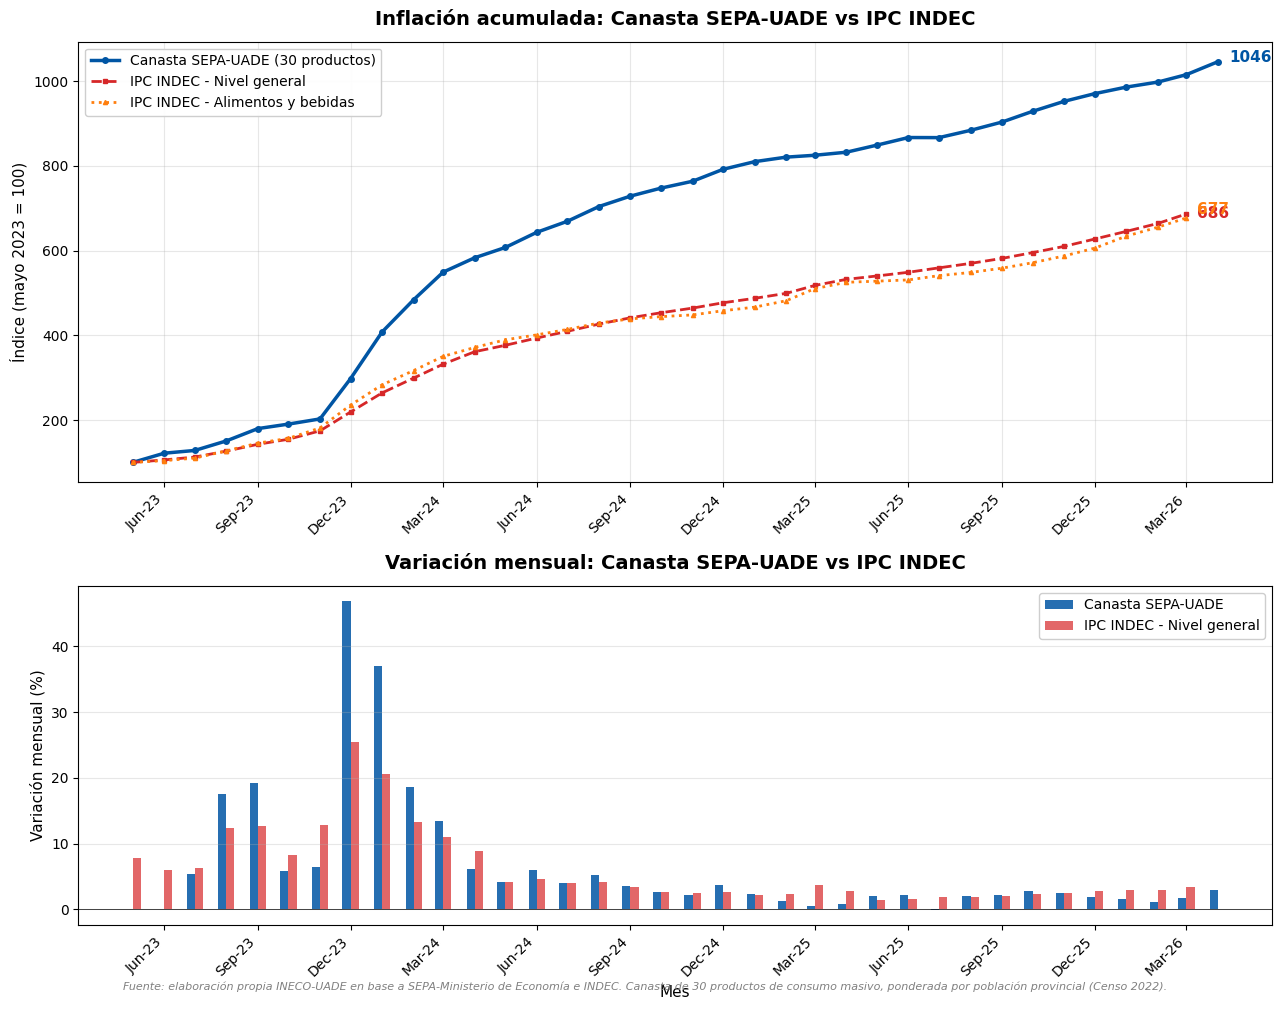


✅ Gráfico guardado en: /content/grafico_canasta_vs_ipc.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELDA 8 — Gráficos comparativos canasta SEPA vs IPC
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Colores institucionales
COLOR_CANASTA = '#0055A4'   # azul UADE
COLOR_IPC_GEN = '#D62728'   # rojo
COLOR_IPC_ALI = '#FF7F0E'   # naranja

# Preparar fechas
df_plot = comparativa.copy()
df_plot['fecha'] = pd.to_datetime(df_plot['mes'] + '-01')
df_plot = df_plot.sort_values('fecha').reset_index(drop=True)

# Crear figura con 2 paneles
fig, axes = plt.subplots(2, 1, figsize=(13, 10), gridspec_kw={'height_ratios': [1.3, 1]})

# ============ PANEL 1: ÍNDICES BASE 100 ============
ax1 = axes[0]
ax1.plot(df_plot['fecha'], df_plot['indice_canasta_base100'],
         color=COLOR_CANASTA, linewidth=2.5,
         label='Canasta SEPA-UADE (30 productos)',
         marker='o', markersize=4)
ax1.plot(df_plot['fecha'], df_plot['indice_ipc_general_base100'],
         color=COLOR_IPC_GEN, linewidth=2,
         label='IPC INDEC - Nivel general',
         linestyle='--', marker='s', markersize=3)
ax1.plot(df_plot['fecha'], df_plot['indice_ipc_alimentos_base100'],
         color=COLOR_IPC_ALI, linewidth=2,
         label='IPC INDEC - Alimentos y bebidas',
         linestyle=':', marker='^', markersize=3)

ax1.set_title('Inflación acumulada: Canasta SEPA-UADE vs IPC INDEC',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Índice (mayo 2023 = 100)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Anotar valor final de la canasta (siempre disponible)
ultimo = df_plot.iloc[-1]
ax1.annotate(f"{ultimo['indice_canasta_base100']:.0f}",
             xy=(ultimo['fecha'], ultimo['indice_canasta_base100']),
             xytext=(8, 0), textcoords='offset points',
             color=COLOR_CANASTA, fontweight='bold', fontsize=11)

# Anotar último valor publicado de IPC (último mes con datos no nulos)
ipc_ultimo = df_plot.dropna(subset=['indice_ipc_general_base100']).iloc[-1]
ax1.annotate(f"{ipc_ultimo['indice_ipc_general_base100']:.0f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['indice_ipc_general_base100']),
             xytext=(8, -3), textcoords='offset points',
             color=COLOR_IPC_GEN, fontweight='bold', fontsize=11)
ax1.annotate(f"{ipc_ultimo['indice_ipc_alimentos_base100']:.0f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['indice_ipc_alimentos_base100']),
             xytext=(8, 3), textcoords='offset points',
             color=COLOR_IPC_ALI, fontweight='bold', fontsize=11)

# ============ PANEL 2: VARIACIONES MENSUALES ============
ax2 = axes[1]
x = df_plot['fecha']
width = pd.Timedelta(days=8)

ax2.bar(x - width/2, df_plot['variacion_mensual_%'], width=width,
        color=COLOR_CANASTA, alpha=0.85, label='Canasta SEPA-UADE')
ax2.bar(x + width/2, df_plot['ipc_general_var_%'], width=width,
        color=COLOR_IPC_GEN, alpha=0.7, label='IPC INDEC - Nivel general')

ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Variación mensual: Canasta SEPA-UADE vs IPC INDEC',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Variación mensual (%)', fontsize=11)
ax2.set_xlabel('Mes', fontsize=11)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Footer
plt.figtext(0.5, 0.005,
            'Fuente: elaboración propia INECO-UADE en base a SEPA-Ministerio de Economía e INDEC. '
            'Canasta de 30 productos de consumo masivo, ponderada por población provincial (Censo 2022).',
            ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.07)

# Guardar
output_png = '/content/grafico_canasta_vs_ipc.png'
plt.savefig(output_png, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Gráfico guardado en: {output_png}")
from google.colab import files
files.download(output_png)

📅 Período de los gráficos: desde 2024-03 hasta 2026-04
   26 meses



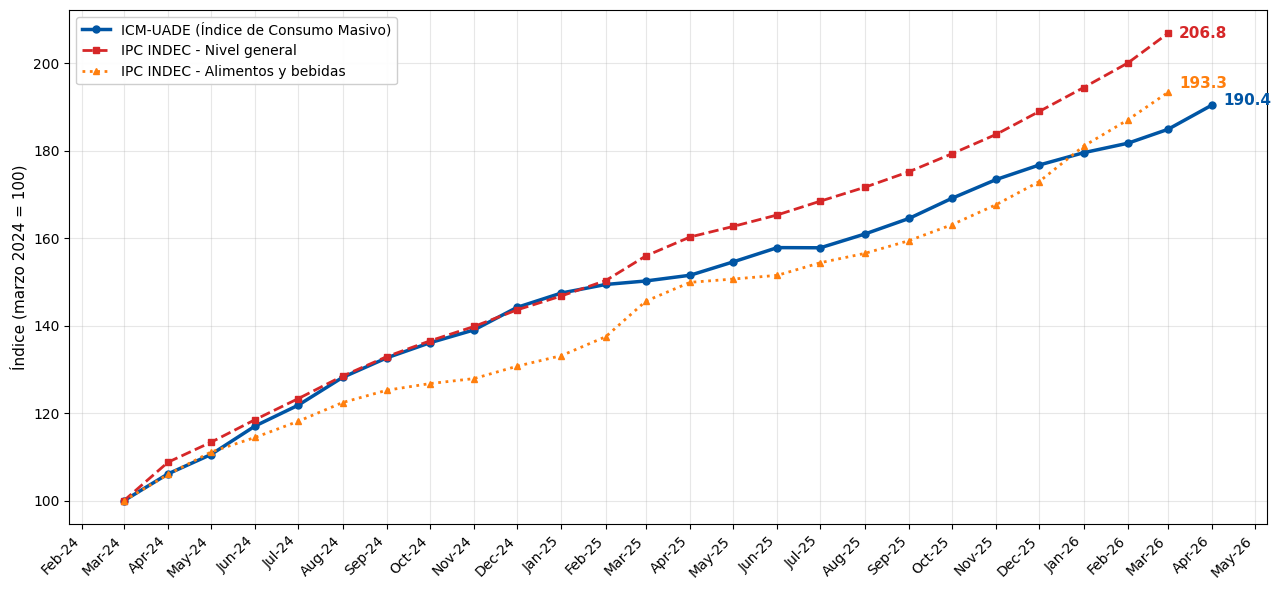

✅ Gráfico 1 (índices) guardado en: /content/grafico_indices_desde_mar24.png


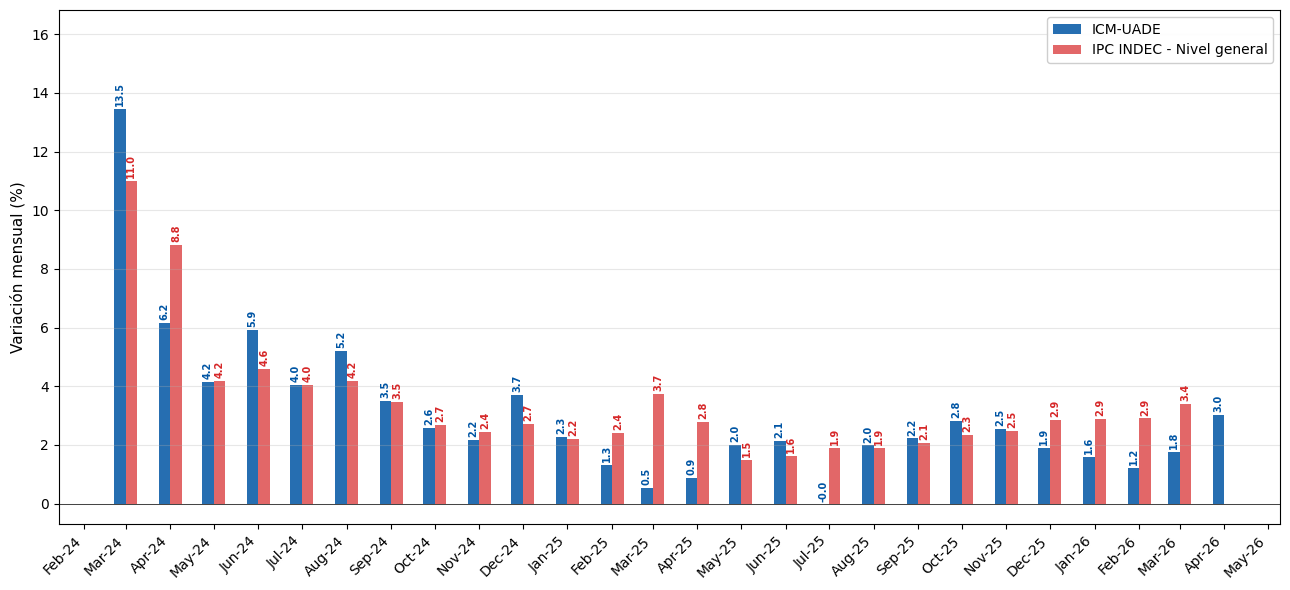

✅ Gráfico 2 (variaciones) guardado en: /content/grafico_variaciones_desde_mar24.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELDA 9 — Gráficos separados: desde marzo 2024 (vista reciente)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Colores institucionales
COLOR_CANASTA = '#0055A4'
COLOR_IPC_GEN = '#D62728'
COLOR_IPC_ALI = '#FF7F0E'

# Período de análisis para estos gráficos
MES_INICIO_GRAFICO = '2024-03'

# Preparar dataframe filtrado
df_g = comparativa[comparativa['mes'] >= MES_INICIO_GRAFICO].copy()
df_g = df_g.sort_values('mes').reset_index(drop=True)
df_g['fecha'] = pd.to_datetime(df_g['mes'] + '-01')

# Reindexar a base 100 = marzo 2024 (primer mes del filtro)
base_canasta = df_g['canasta_nacional_ponderada'].iloc[0]
df_g['idx_canasta_mar24'] = (df_g['canasta_nacional_ponderada'] / base_canasta * 100).round(2)

base_ipc_gen = df_g['ipc_general'].iloc[0]
df_g['idx_ipc_general_mar24'] = (df_g['ipc_general'] / base_ipc_gen * 100).round(2)

base_ipc_alim = df_g['ipc_alimentos'].iloc[0]
df_g['idx_ipc_alimentos_mar24'] = (df_g['ipc_alimentos'] / base_ipc_alim * 100).round(2)

print(f"📅 Período de los gráficos: desde {df_g['mes'].iloc[0]} hasta {df_g['mes'].iloc[-1]}")
print(f"   {len(df_g)} meses\n")

# ============================================================
# GRÁFICO 1 — Índices base 100 (mar-24 = 100)
# ============================================================
fig1, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(df_g['fecha'], df_g['idx_canasta_mar24'],
         color=COLOR_CANASTA, linewidth=2.5,
         label='ICM-UADE (Índice de Consumo Masivo)',
         marker='o', markersize=5)
ax1.plot(df_g['fecha'], df_g['idx_ipc_general_mar24'],
         color=COLOR_IPC_GEN, linewidth=2,
         label='IPC INDEC - Nivel general',
         linestyle='--', marker='s', markersize=4)
ax1.plot(df_g['fecha'], df_g['idx_ipc_alimentos_mar24'],
         color=COLOR_IPC_ALI, linewidth=2,
         label='IPC INDEC - Alimentos y bebidas',
         linestyle=':', marker='^', markersize=4)

ax1.set_ylabel('Índice (marzo 2024 = 100)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Anotar valor final del ICM-UADE (último mes disponible)
ultimo = df_g.iloc[-1]
ax1.annotate(f"{ultimo['idx_canasta_mar24']:.1f}",
             xy=(ultimo['fecha'], ultimo['idx_canasta_mar24']),
             xytext=(8, 0), textcoords='offset points',
             color=COLOR_CANASTA, fontweight='bold', fontsize=11)

# Anotar último valor publicado de IPC
ipc_ultimo = df_g.dropna(subset=['idx_ipc_general_mar24']).iloc[-1]
ax1.annotate(f"{ipc_ultimo['idx_ipc_general_mar24']:.1f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['idx_ipc_general_mar24']),
             xytext=(8, -3), textcoords='offset points',
             color=COLOR_IPC_GEN, fontweight='bold', fontsize=11)
ax1.annotate(f"{ipc_ultimo['idx_ipc_alimentos_mar24']:.1f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['idx_ipc_alimentos_mar24']),
             xytext=(8, 3), textcoords='offset points',
             color=COLOR_IPC_ALI, fontweight='bold', fontsize=11)

plt.tight_layout()
output_png1 = '/content/grafico_indices_desde_mar24.png'
plt.savefig(output_png1, dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Gráfico 1 (índices) guardado en: {output_png1}")

# ============================================================
# GRÁFICO 2 — Variaciones mensuales (con etiquetas)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(13, 6))

x = df_g['fecha']
width = pd.Timedelta(days=8)

# Barras
bars_canasta = ax2.bar(x - width/2, df_g['variacion_mensual_%'], width=width,
                       color=COLOR_CANASTA, alpha=0.85, label='ICM-UADE')
bars_ipc = ax2.bar(x + width/2, df_g['ipc_general_var_%'], width=width,
                   color=COLOR_IPC_GEN, alpha=0.7, label='IPC INDEC - Nivel general')

# Etiquetas sobre cada barra del ICM-UADE
for bar, valor in zip(bars_canasta, df_g['variacion_mensual_%']):
    if pd.notna(valor):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{valor:.1f}',
                 ha='center', va='bottom',
                 fontsize=7, color=COLOR_CANASTA,
                 fontweight='bold', rotation=90)

# Etiquetas sobre cada barra del IPC
for bar, valor in zip(bars_ipc, df_g['ipc_general_var_%']):
    if pd.notna(valor):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{valor:.1f}',
                 ha='center', va='bottom',
                 fontsize=7, color=COLOR_IPC_GEN,
                 fontweight='bold', rotation=90)

ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Variación mensual (%)', fontsize=11)
ax2.set_xlabel('', fontsize=11)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Ampliar margen superior para que entren las etiquetas
ymax = max(df_g['variacion_mensual_%'].max(), df_g['ipc_general_var_%'].max())
ax2.set_ylim(top=ymax * 1.25)

plt.tight_layout()
output_png2 = '/content/grafico_variaciones_desde_mar24.png'
plt.savefig(output_png2, dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Gráfico 2 (variaciones) guardado en: {output_png2}")

# Descargar ambos
from google.colab import files
files.download(output_png1)
files.download(output_png2)

In [ ]:
# ============================================================
# CELDA 10 — Tabla de canasta por provincia (último mes disponible)
# ============================================================
import os
import pandas as pd
import numpy as np

# El último mes disponible se detecta automáticamente
ULTIMO_MES = serie_provincia_valida['mes'].max()
print(f"📅 Último mes disponible: {ULTIMO_MES}\n")

# Filtrar al último mes
df_mes = serie_provincia_valida[serie_provincia_valida['mes'] == ULTIMO_MES].copy()

# Promedio nacional ponderado por población (del archivo nacional consolidado)
promedio_nacional = serie_nacional_valida[
    serie_nacional_valida['mes'] == ULTIMO_MES
]['canasta_nacional_ponderada'].iloc[0]

print(f"💰 Canasta nacional ponderada ({ULTIMO_MES}): ${promedio_nacional:,.2f}\n")

# Calcular diferencia porcentual vs promedio nacional
df_mes['vs_promedio_pais_%'] = (
    (df_mes['canasta_total'] / promedio_nacional - 1) * 100
).round(2)

# Ordenar de menor a mayor canasta
df_mes = df_mes.sort_values('canasta_total').reset_index(drop=True)

# Mostrar la tabla en consola con formato argentino (puntos para miles, comas para decimales)
def formato_ar(x, decimales=0):
    """Convierte un número al formato argentino: 314.883 o 314.883,45."""
    s = f"{x:,.{decimales}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")

print("=== TABLA DE CANASTA POR PROVINCIA ===\n")
print(f"{'Provincia':<22} {'Canasta':>14} {'Vs. promedio país':>20}")
print("-" * 60)
for _, row in df_mes.iterrows():
    canasta_fmt = formato_ar(row['canasta_total'], 0)
    var_fmt = f"{row['vs_promedio_pais_%']:+.2f}%".replace(".", ",")
    print(f"{row['provincia']:<22} {canasta_fmt:>14} {var_fmt:>20}")
print("-" * 60)
print(f"{'Promedio nacional':<22} {formato_ar(promedio_nacional, 0):>14} {'0,00%':>20}\n")

# ============================================================
# Exportar a LaTeX para pegar directamente en el documento
# ============================================================
nombre_mes = {
    '01':'enero','02':'febrero','03':'marzo','04':'abril','05':'mayo','06':'junio',
    '07':'julio','08':'agosto','09':'septiembre','10':'octubre','11':'noviembre','12':'diciembre'
}
anio = ULTIMO_MES[:4]
mes_str = nombre_mes[ULTIMO_MES[5:7]]

latex_lines = []
latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"\centering")
latex_lines.append(r"\renewcommand{\arraystretch}{1.15}")
latex_lines.append(f"\\caption{{Valor de la canasta por provincia y diferencia respecto al promedio nacional ({mes_str} {anio})}}")
latex_lines.append(r"\begin{tabular}{@{}l r r@{}}")
latex_lines.append(r"\toprule")
latex_lines.append(r"\textbf{Provincia} & ")
latex_lines.append(r"\textbf{Canasta} & ")
latex_lines.append(r"\shortstack{\textbf{Vs. promedio}\\\textbf{país (\%)}} \\")
latex_lines.append(r"\midrule")

for _, row in df_mes.iterrows():
    canasta_fmt = formato_ar(row['canasta_total'], 0)
    var_fmt = f"{row['vs_promedio_pais_%']:+.2f}".replace(".", ",")
    latex_lines.append(f"{row['provincia']:<22} & {canasta_fmt} & {var_fmt}\\% \\\\")

latex_lines.append(r"\midrule")
latex_lines.append(f"\\textbf{{Promedio}} & {formato_ar(promedio_nacional, 0)} & 0,00\\% \\\\")
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}\\[0.2cm]")
latex_lines.append(r"\caption*{Fuente: Elaboración propia en base a datos del Sistema Electrónico de Publicidad de Precios Argentinos (SEPA)}")
latex_lines.append(r"\label{tab:canasta_provincias}")
latex_lines.append(r"\end{table}")

latex_output = "\n".join(latex_lines)

# Guardar a archivo
output_tex = f'/content/tabla_canasta_provincias_{ULTIMO_MES}.tex'
with open(output_tex, 'w', encoding='utf-8') as f:
    f.write(latex_output)

print("\n=== CÓDIGO LATEX (copiar y pegar en el informe) ===\n")
print(latex_output)
print(f"\n✅ También guardado en: {output_tex}")

from google.colab import files
files.download(output_tex)

📅 Último mes disponible: 2026-04

💰 Canasta nacional ponderada (2026-04): $322,566.33

=== TABLA DE CANASTA POR PROVINCIA ===

Provincia                     Canasta    Vs. promedio país
------------------------------------------------------------
Córdoba                       309.694               -3,99%
Entre Ríos                    315.110               -2,31%
Tucumán                       316.224               -1,97%
Misiones                      317.135               -1,68%
Formosa                       317.186               -1,67%
Santiago del Estero           318.473               -1,27%
Chaco                         318.963               -1,12%
Corrientes                    321.660               -0,28%
San Juan                      322.142               -0,13%
Mendoza                       323.647               +0,33%
Santa Fe                      323.701               +0,35%
Buenos Aires                  324.062               +0,46%
CABA                          325.410        

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📅 Mapa para: 2026-04

✅ Todas las provincias matchean



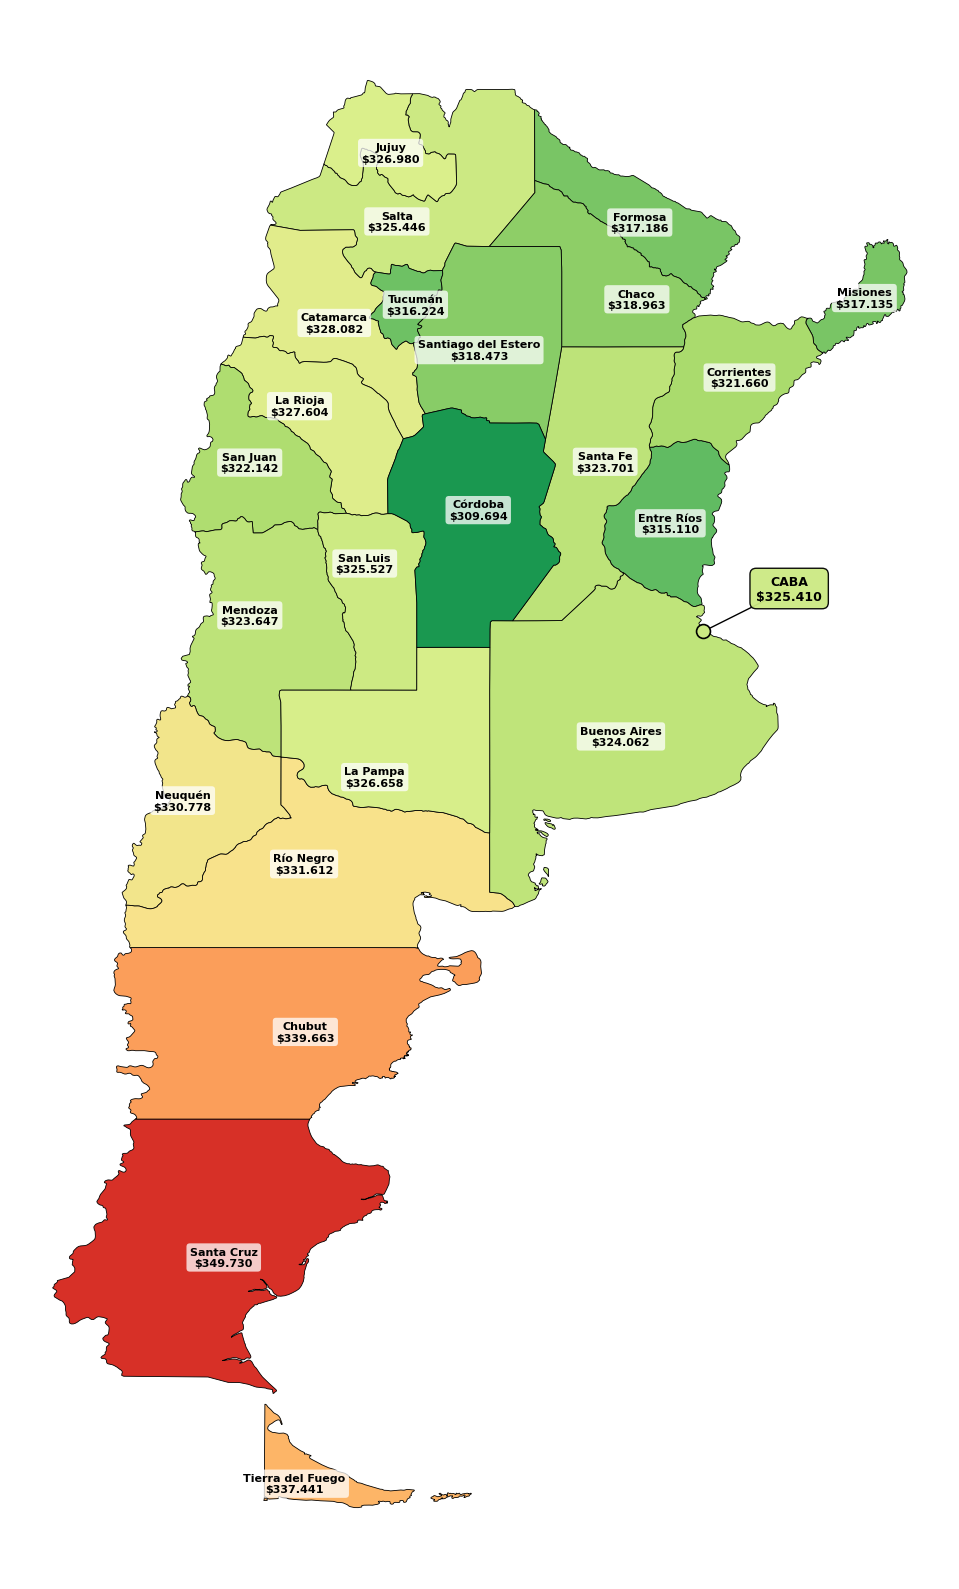


✅ Mapa guardado en: /content/mapa_canasta_2026-04.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELDA 11 — Mapa coroplético con etiquetas (versión ajustada)
# ============================================================
import json
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

GEOJSON_PATH = "/content/ar.json"

# Detectar último mes disponible
ULTIMO_MES = serie_provincia_valida['mes'].max()
print(f"📅 Mapa para: {ULTIMO_MES}\n")

# Filtrar canasta del último mes
df_mes = serie_provincia_valida[serie_provincia_valida['mes'] == ULTIMO_MES].copy()
canastas = dict(zip(df_mes['provincia'], df_mes['canasta_total']))

# Cargar GeoJSON
with open(GEOJSON_PATH, 'r', encoding='utf-8') as f:
    geo = json.load(f)

NORMALIZAR_GEO = {'Ciudad de Buenos Aires': 'CABA'}

# Verificar matches
provincias_geo = {NORMALIZAR_GEO.get(f['properties']['name'], f['properties']['name'])
                  for f in geo['features']}
provincias_datos = set(canastas.keys())
if provincias_geo == provincias_datos:
    print("✅ Todas las provincias matchean\n")

# Paleta de colores
valores = list(canastas.values())
vmin, vmax = min(valores), max(valores)
norm = Normalize(vmin=vmin, vmax=vmax)
colores_lista = ['#1a9850', '#66bd63', '#a6d96a', '#d9ef8b',
                 '#fee08b', '#fdae61', '#f46d43', '#d73027']
cmap = LinearSegmentedColormap.from_list('canasta_cmap', colores_lista, N=256)

def calcular_centroide(coords):
    xs, ys = [], []
    if isinstance(coords[0][0][0], (int, float)):
        for pt in coords[0]:
            xs.append(pt[0]); ys.append(pt[1])
    else:
        poly_mayor = max(coords, key=lambda p: len(p[0]))
        for pt in poly_mayor[0]:
            xs.append(pt[0]); ys.append(pt[1])
    return (sum(xs)/len(xs), sum(ys)/len(ys))

def dibujar_poligono(ax, coords, color, edge='black', alpha=1.0, linewidth=0.6):
    if isinstance(coords[0][0][0], (int, float)):
        xs = [c[0] for c in coords[0]]
        ys = [c[1] for c in coords[0]]
        ax.fill(xs, ys, facecolor=color, edgecolor=edge, linewidth=linewidth, alpha=alpha)
    else:
        for poly in coords:
            xs = [c[0] for c in poly[0]]
            ys = [c[1] for c in poly[0]]
            ax.fill(xs, ys, facecolor=color, edgecolor=edge, linewidth=linewidth, alpha=alpha)

def formato_ar(x):
    return f"{x:,.0f}".replace(",", ".")

# ============ DIBUJAR EL MAPA ============
fig, ax = plt.subplots(figsize=(12, 16))

# Ajustes finos de posición de etiquetas (offset_x, offset_y) en grados
AJUSTES_ETIQUETA = {
    'Salta':             (0.0, -1.0),    # más abajo
    'Tucumán':           (0.3, 0.0),     # un poco a la derecha
    'Chaco':             (0.0, -1.0),    # más abajo
    'Tierra del Fuego':  (-1.0, -0.2),    # a la izquierda
    'Santa Fe':          (0.0, 1.0),     # un poco más arriba
    'Santiago del Estero': (0.7, 0.0),    #
}

# Coordenadas de CABA (centroide real para dibujar flecha)
caba_centroide = None

for feat in geo['features']:
    nombre_geo = feat['properties']['name']
    nombre = NORMALIZAR_GEO.get(nombre_geo, nombre_geo)

    if nombre in canastas:
        valor = canastas[nombre]
        color = cmap(norm(valor))
    else:
        color = '#cccccc'
        valor = None

    geom_type = feat['geometry']['type']
    coords = feat['geometry']['coordinates']

    if geom_type == 'Polygon':
        dibujar_poligono(ax, [coords], color)
    else:
        dibujar_poligono(ax, coords, color)

    cx, cy = calcular_centroide([coords] if geom_type == 'Polygon' else coords)

    # Guardar centroide real de CABA para la flecha (no etiquetar acá)
    if nombre == 'CABA':
        caba_centroide = (cx, cy)
        continue

    dx, dy = AJUSTES_ETIQUETA.get(nombre, (0, 0))
    cx += dx
    cy += dy

    if valor is not None:
        label = f"{nombre}\n${formato_ar(valor)}"
        ax.text(cx, cy, label, ha='center', va='center',
                fontsize=8, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.75,
                          edgecolor='none'))
    else:
        ax.text(cx, cy, nombre, ha='center', va='center',
                fontsize=8, color='black')

# ============ CABA APARTE (con flecha + inset ampliado) ============
if caba_centroide and 'CABA' in canastas:
    valor_caba = canastas['CABA']
    color_caba = cmap(norm(valor_caba))

    # Posición de la etiqueta de CABA: a la derecha del mapa, frente a Buenos Aires
    caba_label_x = caba_centroide[0] + 2
    caba_label_y = caba_centroide[1] + 1

    # Flecha desde CABA hasta la etiqueta
    ax.annotate(
        '',
        xy=caba_centroide,
        xytext=(caba_label_x, caba_label_y),
        arrowprops=dict(arrowstyle='-', color='black', linewidth=1.0)
    )

    # Recuadro destacado para CABA (más grande, con su color)
    ax.text(caba_label_x, caba_label_y,
            f"CABA\n${formato_ar(valor_caba)}",
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.5',
                      facecolor=color_caba, alpha=0.95,
                      edgecolor='black', linewidth=1.0))

    # Marcar CABA en el mapa con un círculo destacado (para que se vea aunque sea chica)
    ax.plot(caba_centroide[0], caba_centroide[1],
            marker='o', markersize=10, markerfacecolor=color_caba,
            markeredgecolor='black', markeredgewidth=1.2, zorder=5)

ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()

output_png = f'/content/mapa_canasta_{ULTIMO_MES}.png'
plt.savefig(output_png, dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Mapa guardado en: {output_png}")
from google.colab import files
files.download(output_png)